## Punto Uno.

Usando un asistente computacional, realice el campo de pendientes junto
con la gráfica de la familia de soluciones de la ecuación diferencial.
Además, realice la gráfica de la solución particular para el problema de
valor inicial dado; si no tiene condición inicial, elija una.

### Función de dibujo

Con el objetivo de optimizar el espacio de la presente guia, y evitar escribir código repetitivo, iniciaremos por crear una función que se encargará de dibujar las gráficas solicitadas, según los datos de cada ejercicio.

In [105]:
import numpy as np
import matplotlib.pyplot as plt # type: ignore
from scipy.integrate import solve_ivp

def draw(h_in, f_in, piv):
    f = f_in
    h = h_in  # separacion de malla
    m = np.arange(-15, 16)
    n = np.arange(-20, 21)
    X, Y = np.meshgrid(m*h, n*h)

    pendiente = f(X, Y)
    norm = np.sqrt(1 + pendiente**2)
    U = 1 / norm          # componente horizontal (unitaria)
    V = pendiente / norm  # componente vertical

    fig, ax = plt.subplots()
    ax.quiver(X, Y, U, V, angles='xy', color='navy')  # flechas
    ax.set_xlim(-7, 7)
    ax.set_ylim(-10, 5)

    # evento: detiene la integracion si |y| crece demasiado (evita overflow)
    def blow_up(t, y):
        return abs(y[0]) - 50
    blow_up.terminal = True

    # --- familia de soluciones ---
    x_eval = np.linspace(-7, 7, 400)
    condiciones_iniciales = np.arange(-5, 5.5, 0.5)

    for y0 in condiciones_iniciales:    
        sol = solve_ivp(f, [0, 7], [y0], t_eval=x_eval[x_eval >= 0], dense_output=True)
        sol_back = solve_ivp(f, [0, -7], [y0], t_eval=x_eval[x_eval <= 0][::-1], dense_output=True)

        ax.plot(sol.t, sol.y[0], color='#5F9EA0', linewidth=1)
        ax.plot(sol_back.t, sol_back.y[0], color='#5F9EA0', linewidth=1)

# --- solucion particular y(x0) = y0 ---
    x0_particular, y0_particular = piv

    sol_p = solve_ivp(f, [x0_particular, 7], [y0_particular],
                       t_eval=x_eval[x_eval >= x0_particular], dense_output=True)
    sol_p_back = solve_ivp(f, [x0_particular, -7], [y0_particular],
                            t_eval=x_eval[x_eval <= x0_particular][::-1], dense_output=True)

    ax.plot(sol_p.t, sol_p.y[0], color='black', linewidth=1.2,
            label=f'y({x0_particular}) = {y0_particular}')
    ax.plot(sol_p_back.t, sol_p_back.y[0], color='black', linewidth=1.2)
    ax.legend()

    plt.show()

### a.  $ \small y'=-y-\sin(x)$, con $y(0)=1$

#### **Caracterización:**
* Ecuación diferencial ordinaria, en donde solo tenemos una variable independiente, en este caso: $x$  
* EDO de primer orden, pues aparece unicamente $y'$
* Es lineal porque los terminos $y$ y $y'$ son de primer grado y no se multiplican entre ellos.

#### **Gráfica:**

A continuación, presentamos el diagrama del campo de pendientes, la familia de soluciones (en color azul claro) y la solución particular para $y(0)=1$ (en color negro)

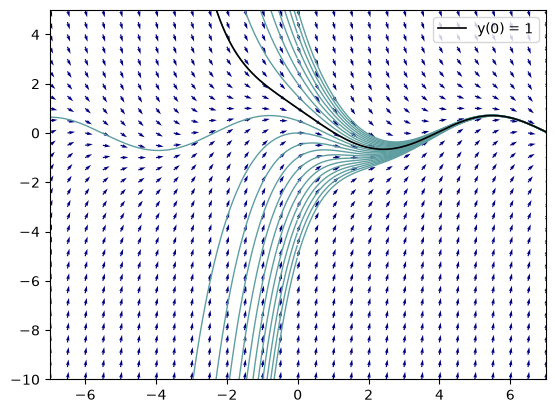

In [106]:
def fa(x, y):
    return - y - np.sin(x)

draw(float(0.5), fa, (0, 1))

### b.  $\small y'=x+y$, con $y(-2)=2$

#### **Caracterización:**
* Ecuación diferencial ordinaria, en donde solo hay una variable independiente identificada con $x$  
* EDO de primer orden, observando que aparece unicamente $y'$
* EDO lineal, siendo $y$ y $y'$ de primer grado y no multiplicándose entre ellos.

#### **Gráfica:**

A continuación, presentamos el diagrama del campo de pendientes, la familia de soluciones (en color azul claro) y la solución particular para $y(-2)=2$ (en color negro)

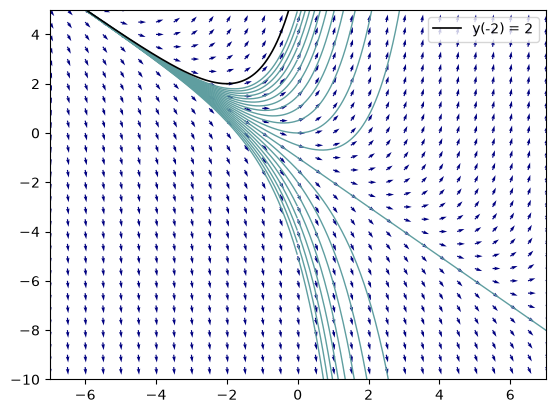

In [107]:
def fb(x, y):
    return x + y

draw(float(0.5), fb, (-2, 2))

### c.  $\small y'=-x^2+\sin(y)$

#### **Caracterización:**
* Ecuación diferencial ordinaria, en donde solo tenemos una variable independiente, en este caso: $x$  
* EDO de primer orden, debido a que aparece unicamente $y'$
* EDO no lineal, pues incluye una función no lineal que depende de $y$, la cual es $\sin(y)$.

#### **Gráfica:**

A continuación, presentamos el diagrama del campo de pendientes, la familia de soluciones (en color azul claro) y la solución particular para $y(0)=0$ (en color negro)

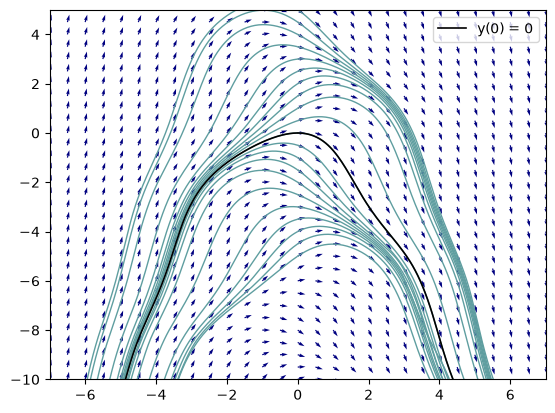

In [108]:
def fc(x, y):
    return - x + np.sin(y)

draw(float(0.5), fc, (0, 0))

### d.  $\small (x^2+1)y'+3xy=6x$

Inicialmente vamos a reescribir la ecuación para despejar $y'$, con el objetivo de evidenciar de mejor forma las características de la ecuación diferencial y lograr graficarla adecuadamente.

#### **Caracterización:**
* Ecuación diferencial ordinaria, teniendo una única variable independiente que es $x$  
* EDO de primer orden, pues la derivada de mayor orden es $y'$
* EDO lineal en donde los terminos $y$ y $y'$ son de primer grado y sus coeficientes no dependen de $y$.

#### **Gráfica:**

A continuación, presentamos el diagrama del campo de pendientes, la familia de soluciones (en color azul claro) y la solución particular para $y(2)=1$ (en color negro)

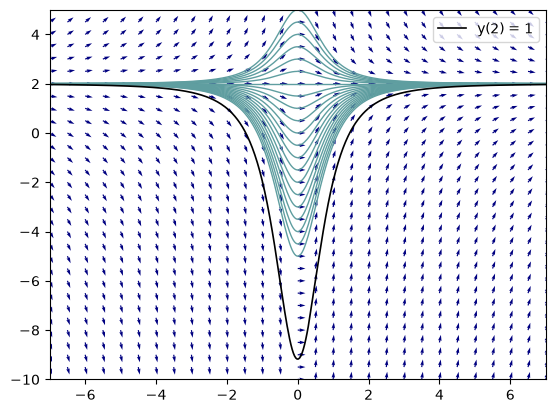

In [109]:
def fd(x, y):
    return (6*x - 3*x*y)/(x*x + 1)

draw(float(0.5), fd, (2, 1))

### e.  $\small y'=xe^y$

#### **Caracterización:**
* Ecuación diferencial ordinaria, en donde solo existe una variable independiente representada con $x$  
* EDO de primer orden, porque la derivada de mayor orden presente es $y'$
* EDO no lineal pues existe una función lineal que depende de $y$

#### **Gráfica:**

A continuación, presentamos el diagrama del campo de pendientes, la familia de soluciones (en color azul claro) y la solución particular para $y(0)=1$ (en color negro)

C:\Users\valer\AppData\Local\Temp\ipykernel_31388\2902540203.py:2: RuntimeWarning: overflow encountered in exp
  return x * np.exp(y)


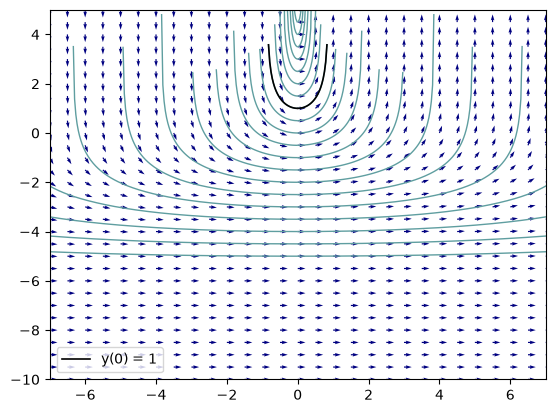

In [110]:
def fe(x, y):
    return x * np.exp(y)

draw(float(0.5), fe, (0, 1 ))

### f.  $\small y'=x-y$, con $y(1)=1$

#### **Caracterización:**
* Ecuación diferencial ordinaria, pues únicamente tenemos una variable independiente llamada $x$  
* EDO de primer orden, debido a que aparece unicamente $y'$
* EDO lineal en la que vemos que los terminos $y$ y $y'$ son de primer grado y no se multiplican entre ellos.

#### **Gráfica:**

A continuación, presentamos el diagrama del campo de pendientes, la familia de soluciones (en color azul claro) y la solución particular para $y(1)=1$ (en color negro)

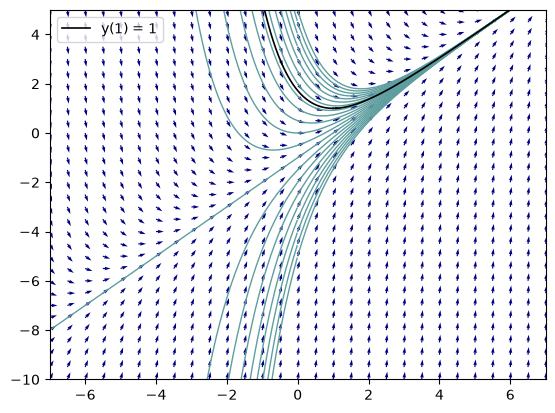

In [112]:
def ff(x, y):
    return x - y

draw(float(0.5), ff, (1, 1))